<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Why a Plain Autoencoder Cannot Generate</b>
</h1>
<div style="font-family:'Times New Roman';">
Back in Day 47 the autoencoder compressed a digit into a small code and rebuilt it. The obvious next thought is, feed it a random code and get a new digit for free. It does not work, and finding out why is the whole reason the VAE exists.
</div>

## setting up on mnist

sklearn can fetch mnist. it downloads once and then sits in `~/scikit_learn_data`, so after the first run its offline. using 10000 images to keep everything fast.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

torch.manual_seed(0)

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='liac-arff')
X = torch.tensor(mnist.data[:10000] / 255.0, dtype=torch.float32)
y = mnist.target[:10000].astype(int)

print("data :", X.shape, " pixel range", X.min().item(), "to", X.max().item())

data : torch.Size([10000, 784])  pixel range 0.0 to 1.0


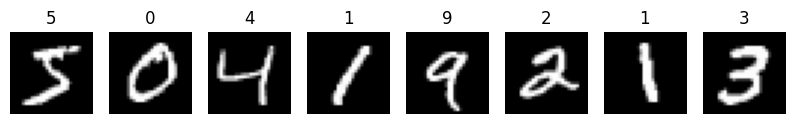

In [3]:
fig, ax = plt.subplots(1, 8, figsize=(10,1.6))
for i in range(8):
    ax[i].imshow(X[i].reshape(28,28), cmap='gray')
    ax[i].set_title(y[i]); ax[i].axis('off')
plt.show()

## a plain autoencoder, same as Day 47 but on 28x28

encoder squeezes 784 pixels into 2 numbers so the latent space can be drawn. 2 is small, the reconstructions will be rough, but seeing the space matters more here.

In [5]:
L = 2

encoder = nn.Sequential(nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, L))
decoder = nn.Sequential(nn.Linear(L, 256), nn.ReLU(), nn.Linear(256, 784), nn.Sigmoid())

params = list(encoder.parameters()) + list(decoder.parameters())
opt = torch.optim.Adam(params, lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(40):
    perm = torch.randperm(len(X))
    total = 0
    for i in range(0, len(X), 256):
        xb = X[perm[i:i+256]]
        out = decoder(encoder(xb))
        loss = loss_fn(out, xb)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    if epoch % 10 == 0:
        print("epoch", str(epoch).rjust(2), " mse", round(total / (len(X)//256), 5))

epoch  0  mse 0.10178


epoch 10  mse 0.05118


epoch 20  mse 0.04852


epoch 30  mse 0.04703


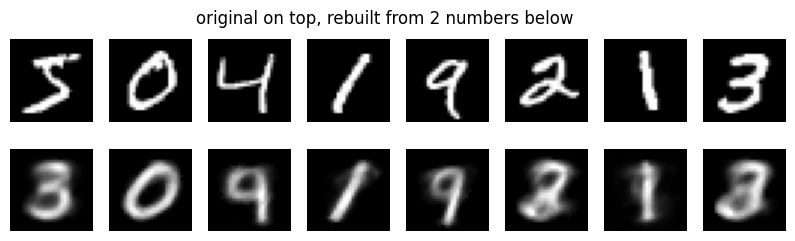

In [6]:
with torch.no_grad():
    rebuilt = decoder(encoder(X[:8]))

fig, ax = plt.subplots(2, 8, figsize=(10,2.6))
for i in range(8):
    ax[0,i].imshow(X[i].reshape(28,28), cmap='gray'); ax[0,i].axis('off')
    ax[1,i].imshow(rebuilt[i].reshape(28,28), cmap='gray'); ax[1,i].axis('off')
plt.suptitle('original on top, rebuilt from 2 numbers below')
plt.show()

blurry but the digit is usually there, from only 2 numbers. reconstruction works.

## now the generating part

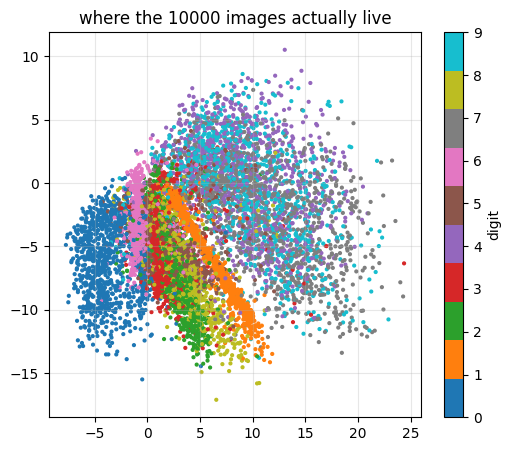

code range : x from -7.7 to 24.4
             y from -17.1 to 10.5


In [7]:
with torch.no_grad():
    codes = encoder(X).numpy()

plt.figure(figsize=(6,5))
sc = plt.scatter(codes[:,0], codes[:,1], c=y, cmap='tab10', s=4)
plt.colorbar(sc, label='digit')
plt.title('where the 10000 images actually live')
plt.grid(alpha=.3)
plt.show()

print("code range : x from", round(codes[:,0].min(),1), "to", round(codes[:,0].max(),1))
print("             y from", round(codes[:,1].min(),1), "to", round(codes[:,1].max(),1))

two things to notice. the codes run from about -8 to +24 on one axis and -17 to +11 on the other, so the scale is arbitrary, and there are gaps between the clusters.

the arbitrary scale is already a problem on its own. to sample a new code i have to first go and **look** at the trained model to find out what range its codes live in. there is no rule saying it should be this range, another training run gives another range.

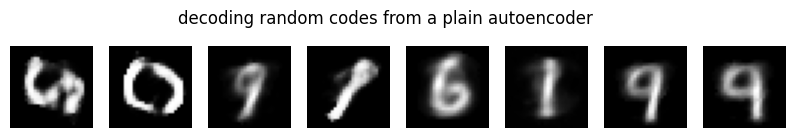

In [9]:
torch.manual_seed(3)
z_random = torch.randn(8, L) * 10        # roughly the scale of the real codes

with torch.no_grad():
    made_up = decoder(z_random)

fig, ax = plt.subplots(1, 8, figsize=(10,1.6))
for i in range(8):
    ax[i].imshow(made_up[i].reshape(28,28), cmap='gray'); ax[i].axis('off')
plt.suptitle('decoding random codes from a plain autoencoder')
plt.show()

not what i expected. two of the eight are broken blobs, but the rest are recognisable digits.

the real problem is visible in a diffrent way though. look at what came out, its four 9s, a 6 and a 1. i cannot ask for a 3, and i cannot even get a good spread of digits, i get whatever the biggest region of the space happens to be. and i had to multiply by 10 by hand to get the scale right in the first place.

so the failure is not that every sample is garbage. it is that some are, there is no control over what comes out, and i had to inspect the model to know how to sample at all.

grid cells with no training image nearby : 25.4 %


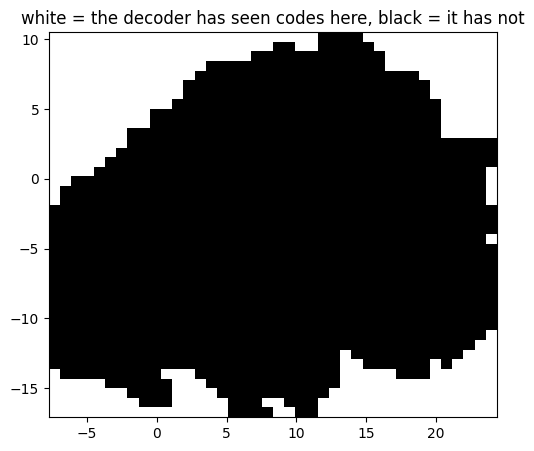

In [11]:
# grid over the code space, colour by whether any real image is nearby
gx = np.linspace(codes[:,0].min(), codes[:,0].max(), 40)
gy = np.linspace(codes[:,1].min(), codes[:,1].max(), 40)
occupied = np.zeros((40, 40))

for i, xv in enumerate(gx):
    for j, yv in enumerate(gy):
        d = np.hypot(codes[:,0] - xv, codes[:,1] - yv)
        occupied[j, i] = (d < 1.5).sum()

print("grid cells with no training image nearby :",
      round(100 * (occupied == 0).mean(), 1), "%")

plt.figure(figsize=(6,5))
plt.imshow(occupied > 0, origin='lower', cmap='Greys',
           extent=[gx[0], gx[-1], gy[0], gy[-1]])
plt.title('white = the decoder has seen codes here, black = it has not')
plt.show()

two ideas, and both are about the **shape of the latent space**, not about the network:

1. the encoder outputs a **mean and a spread** instead of one point. training samples from that little cloud, so the decoder has to give a sensible digit for a whole neighbourhood, not one exact spot. that fills in the gaps
2. a **KL penalty** pulls all the clouds toward a standard normal, so the codes end up packed around the origin at a known scale

the second one solves the sampling problem completly. after training, the right way to sample is `z ~ N(0,1)`, every time, no need to inspect the model first. that is the thing a plain autoencoder cannot give.

### recap
- a plain autoencoder rebuilds well, and it can sometimes generate by accident
- its latent space has an arbitrary scale, so i had to look at the codes before i could sample at all
- about 25 percent of the space is empty, and samples landing there come out as blobs
- there is no control, my 8 samples were mostly 9s
- the VAE fixes the shape of the space, the encoder and decoder stay basicaly the same. building it in notebook 02